## Code for armA pre (July 21st 2025)

In [1]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [2]:
import marsilea as ma
import marsilea.plotter as mp

In [4]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [5]:
## read in data

arm = 'ArmA_2024/'
log_data = 'CN_pre/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) 

In [6]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None)) 
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 



In [7]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(191512, 31)
(191512, 1)
(191512, 2)


In [8]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
[  307     2    52  4354    59  2151  6074    57    30   312 19648  1069
   267   334 38928    43 67193  8833   316   588 23219  8574  8848   254]


In [9]:
cluster_asgn1 = cluster_asgn.flatten()

#### scanpy trial

In [10]:
import scipy 
import os
import scipy.io as sio
import scanpy as sc

In [11]:

df = count_matrix[:,21:26]
adata = sc.AnnData(df)


adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]

adata.obs["louvain"] = cluster_asgn1
print(adata.var_names[:10])

Index(['Gene_0', 'Gene_1', 'Gene_2', 'Gene_3', 'Gene_4'], dtype='object')


In [12]:
adata

AnnData object with n_obs × n_vars = 191512 × 5
    obs: 'louvain'

In [13]:
y_marker = ['FoxP3','CD3',  'CD8', 'PD1','PDL1' ]
#adata.var_names = y_marker #[f"Gene_{i:d}" for i in range(adata.n_vars)]           
cell_markers = {
    "T reg cells": ["FoXP3"],
    "CD3+ T cells": ["CD3"],
    "CD8 T cells": ["CD8"],
    "PD-1 cells": ["PD-1"],
    "PD-L1 cells": ["PD-L1"],
}

cells, markers = [], []
for c, ms in cell_markers.items():
    cells += [c] * len(ms)
    markers += ms

uni_cells = list(cell_markers.keys())
cell_colors = [
    "#568564",
    "#DC6B19",
    "#F72464",
    "#005585",
    "#9876DE",
    "#405559",
    "#58DADA",
    "#F85959",
]
cmapper = dict(zip(uni_cells, cell_colors))

In [15]:
exp = adata[:, 0:5].X.toarray()



In [17]:
agg = sc.get.aggregate(adata[:, 0:5], by="louvain", func=["mean", "count_nonzero"])
agg.obs["cell_counts"] = adata.obs["louvain"].value_counts()
agg

AnnData object with n_obs × n_vars = 24 × 5
    obs: 'louvain', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [18]:
agg_exp = agg.layers["mean"]
agg_count = agg.layers["count_nonzero"]
agg_cell_counts = adata.obs["louvain"].value_counts().to_numpy()

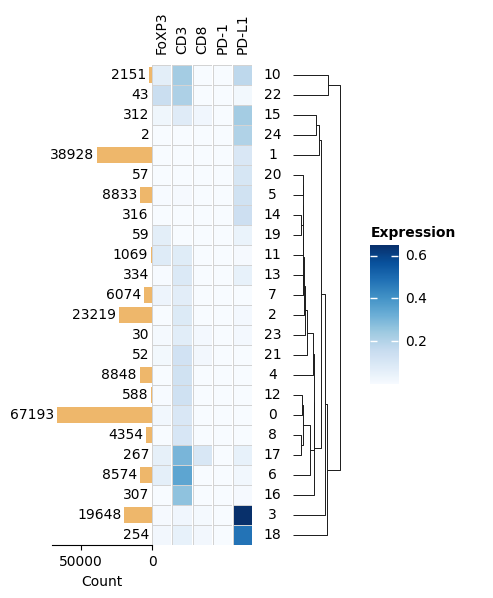

In [19]:
h, w = agg_exp.shape

m = ma.Heatmap(
    agg_exp,
    height=h / 5,
    width=w / 5,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)
m.add_right(mp.Labels(agg.obs["louvain"], align="center"), pad=0.1)

m.add_top(mp.Labels(markers), pad=0.1)

m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.add_left(mp.Numbers(agg_cell_counts, color="#EEB76B", label="Count"))
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

In [20]:
uni_cells

['T reg cells', 'CD3+ T cells', 'CD8 T cells', 'PD-1 cells', 'PD-L1 cells']

### merge clusters 

In [23]:

cluster_asgn2 = np.zeros(cluster_asgn1.shape)

In [24]:
#pdl1
row = np.where(cluster_asgn1==24)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==1)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==20)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==5)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==14)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==3)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==18)
cluster_asgn2[row]=np.int64(100)

#fox cd3
row = np.where(cluster_asgn1==22)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==7)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==6)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==11)
cluster_asgn2[row]=np.int64(600)

#cd3
row = np.where(cluster_asgn1==2)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==23)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==21)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==4)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==12)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==0)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==8)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==16)
cluster_asgn2[row]=np.int64(300)

#fox/cd3/pdl1

row = np.where(cluster_asgn1==15)
cluster_asgn2[row]=np.int64(500)
row = np.where(cluster_asgn1==10)
cluster_asgn2[row]=np.int64(500)

#cd3/8/pdl1/fox
row = np.where(cluster_asgn1==17)
cluster_asgn2[row]=np.int64(500)



#cd3 pdl1
row = np.where(cluster_asgn1==13)
cluster_asgn2[row]=np.int64(200)



#fox/pdl1
row = np.where(cluster_asgn1==19)
cluster_asgn2[row]=np.int64(400)

cluster_asgn2 = np.int64(cluster_asgn2/100)
cluster_asgn2 = cluster_asgn2-1

0
green
1
dimgray
2
orchid
3
darkviolet
4
red
5
orange


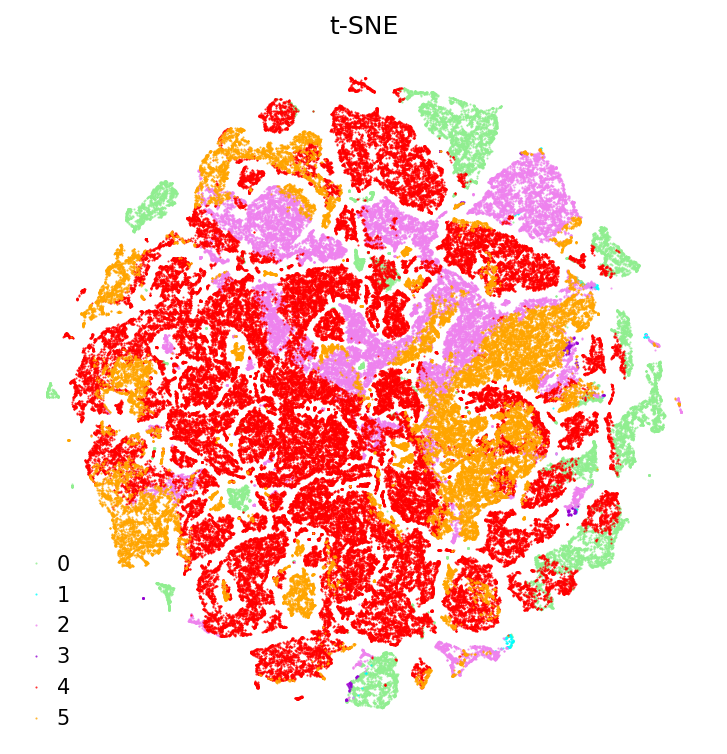

In [25]:
#t-SNE plots
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
plt.figure(figsize=(6,6),dpi=150)
plt.axis('off')
#colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'
colors = ['lightgreen','cyan', 'violet', 'darkviolet', 'red' ,'orange']

for i,  label in zip(target_ids,  unique1):
    print(label)
    c=colours_30[i+3] #cm.colors[i]
    print(c)
    plt.scatter(X_2d_1[ cluster_asgn2==(i), 0], X_2d_1[ cluster_asgn2==(i), 1], color=colors[i],label=label,s=1,linewidths=0,alpha=0.8)
plt.legend(loc=3)
plt.title('t-SNE')
plt.show()


### create a pie chart


In [28]:
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
cell_classes = ['PD-L1+','CD3+ PD-L1+','CD3+','FoxP3+ PD-L1+','FoxP3+ CD3+ CD8+ PD-L1+','FoxP3+ CD3+']
louvain_names = np.zeros(np.shape(cluster_asgn2))
listOfStrings = [" "] * 191512
col_len = []

for i,  label in zip(target_ids,  unique1):
    print(label)
    s= np.array(np.where(cluster_asgn2==label)).flatten()
    print(s.shape)
    print(s)
    col_len.append(np.int64(s.shape))
    for j in range(len(s)):
        listOfStrings[s[j]]=cell_classes[label]
    

0
(16516,)
[     4      7     10 ... 191508 191509 191510]
1
(267,)
[  3059   5992  16709  17002  18373  18375  38197  49487  50018  50022
  50024  50028  50029  50032  50337  50886  77730  80625  80628  80629
  80836  80849  80854  80868  82821  83107  85581  86501  87204  89088
  92191  94003  94277  94278  94283  96843  96872  97975  99017  99020
  99052  99321  99588  99591  99636 110201 110258 110327 110568 110577
 110578 110579 110643 110646 110647 110648 110649 110650 110671 110720
 110727 110753 110754 110755 110826 110827 110828 110829 110830 110832
 110836 110837 110851 110870 110871 110880 110884 110934 110938 110939
 110970 110971 110972 110984 110985 110987 111038 111162 111285 111288
 111316 111339 111344 111346 111348 111356 111480 111603 111614 111626
 111904 111987 111991 111994 111997 112008 112019 112186 112343 112477
 112487 112490 112692 112693 112705 112707 112709 112711 112861 112869
 113100 113104 113115 113183 113401 113404 113406 113411 113478 113518
 113529 1

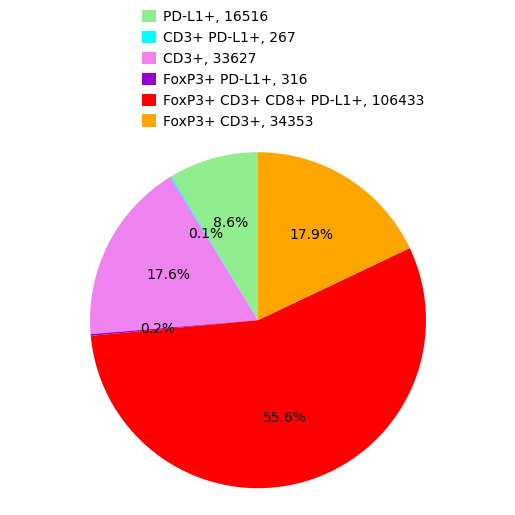

In [29]:
import matplotlib.pyplot as plt
labels = cell_classes#['dogs','cats','birds','fish']
sizes = np.array(col_len).flatten() #[34, 24,18,13]
#c= ["green","dimgray","orchid","darkviolet",
#              "red", "orange","blue"]

colors1 = ['lightgreen','cyan', 'violet', 'darkviolet', 'red' ,'orange','blue']
pie = plt.pie(sizes,autopct='%1.1f%%', startangle=90, colors=colors1)
plt.axis('equal')
plt.legend( loc = 'right', labels=labels)

labels = [f'{l}, {s:0.0f}' for l, s in zip(labels, sizes)]
plt.legend(bbox_to_anchor=(0.85, 1), loc=4, labels=labels)


plt.show()